In [38]:
!pip install prophet
!pip install cmdstanpy==1.2.5

In [39]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet

# Part 1

## Problem 4.5

A time series was generated by first drawing the white noise series $w_t$ froma normal distribution with mean zero and variance one. The observed series $x_t$ was generated from
$$
x_t = w_t - \theta w_{t-1},\ t=0,\pm 1, \pm 2, \dots,
$$
where $\theta$ is a parameter.

### Part (a)

Derive the theoretical mean value and autocovariance functions for the series $x_t$ and $w_t$. Are the series $x_t$ and $w_t$ stationary? Give your reasons.

First find the mean $E[x_t]$ which gives us
$$
E[x_t] = E[w_t - \theta w_{t-1}] \\
E[x_t] = E[w_t] - E[\theta w_{t-1}] \\
E[x_t] = 0 - \theta E[w_{t-1}] \\
E[x_t] = \theta * 0 = 0
$$
We end up with a mean value of 0.

---

Next, let's find the autocovariance functions at different lags and check for stationarity.

Crossterms are just being ignored below instead of writing and then zeroing out.

First is $E[x^2_t]$ for time lag 0
$$
E[x^2_t] = E[(w_t - \theta w_{t-1})^2] \\
E[x^2_t] = E[w^2_t + \theta^2 w_{t-1}^2] \\
E[x^2_t] = E[w^2_t] + \theta^2E[w_{t-1}^2] \\
E[x^2_t] = \sigma^2_w + \theta^2\sigma^2_w \\
E[x^2_t] = \sigma^2_w (1+\theta^2)
$$

Next, check for time lag 1, $E[x_tx_{t-1}]$
$$
E[x_tx_{t-1}] = E[(w_t - \theta w_{t-1})(w_{t-1} - \theta w_{t-2})] \\
E[x_tx_{t-1}] = E[(- \theta w_{t-1})(w_{t-1})] \\
E[x_tx_{t-1}] = - \theta E[w_{t-1}] \\
E[x_tx_{t-1}] = - \theta \sigma^2_w
$$

Then, since we can see there are no more crossterms, we can just state that the autocovariance is 0 for time lag $|h| \ge 2$.

---

Now, let's check for stationarity.

Weak Stationarity Checklist:
1.   The mean is constant and does not depend on time t
2.   The function only depends on lag
3.   The variance is finite

The above passes all three checks so the process is stationary.

### Part (b)

Give a formula for the power spectrum of $x_t$, expressed in terms of $\theta$ and $\omega$.

Power Spectrum Formula
$$
f(\omega) = \frac{1}{2\pi} \sum^{\infty}_{h=-\infty} \gamma(h)e^{-2\pi i\omega h}
$$

Looking at the formula above, we just need to plug in our autocovariance functions, keeping in mind that negative values also count (-1 is just the same as 1).
$$
f(\omega) = \frac{1}{2\pi} [\gamma(-1)e^{-2\pi i\omega (-1)} + \gamma(0)e^{-2\pi i\omega (0)} + \gamma(1)e^{-2\pi i\omega (1)}] \\
f(\omega) = \frac{1}{2\pi} [(-\theta\sigma^2_w)e^{2\pi i\omega} + (\sigma^2_w (1 + \theta^2))(1) + (-\theta\sigma^2_w)e^{-2\pi i\omega}] \\
f(\omega) = \frac{\sigma^2_w}{2\pi} [(-\theta)e^{2\pi i\omega} + (1 + \theta^2) + (-\theta)e^{-2\pi i\omega}] \\
f(\omega) = \frac{\sigma^2_w}{2\pi} [(1 + \theta^2) -\theta (e^{2\pi i\omega} + e^{-2\pi i\omega})] \\
f(\omega) = \frac{\sigma^2_w}{2\pi} [(1 + \theta^2) -\theta (cos(2\pi\omega) + isin(2\pi\omega) + cos(2\pi\omega) - isin(2\pi\omega))] \\
f(\omega) = \frac{\sigma^2_w}{2\pi} [(1 + \theta^2) -\theta (2cos(2\pi\omega))] \\
f(\omega) = \frac{\sigma^2_w}{2\pi} [(1 + \theta^2) -2\theta cos(2\pi\omega)]
$$

# Part 2

## Problem 4.6

A first-order autoregressive model is generated from the white noise series $w_t$ using the generating equations
$$
x_t = \phi x_{t-1} + w_t
$$
where $\phi$, for $|\phi| \lt 1$, is a parameter and the $w_t$ are independent random variables with mean zero and variance $\sigma^2_w$.

### Part (a)

Show that the power spectrum of $x_t$ is given by
$$
f_x(\omega)=\frac{\sigma^2_w}{1+ \phi^2 - 2\phi cos(2\pi \omega)}
$$

For this question, I'll try using the backshift notation and PSD of ARMA process shown in the lecture slides.

First, let's turn the AR(1) model into backshift notation
$$
x_t = \phi x_{t-1} + w_t \\
x_t - \phi x_{t-1} = w_t \\
x_t(1-\phi B) = w_t
$$
This gives us $(1-\phi B)$ for the AR polynomial and 1 for the MA polynomial.

Next, looking at the slides, we know the formula for the PSD an ARMA process
$$
f(\omega) = \sigma^2_w|F[\psi(B)]|^2 \\
f(\omega) = \sigma^2_w |\frac{\theta(e^{-2\pi i \omega})}{\phi (e^{-2\pi i \omega})}|^2
$$

Plugging in our polynomials gives us the following. (had to look up $|z|^2 = z * \bar{z}$)
$$
f(\omega) = \sigma^2_w |\frac{1}{1 - \phi e^{-2\pi i \omega}}|^2 \\
f(\omega) = \sigma^2_w \frac{1}{|1 - \phi e^{-2\pi i \omega}|^2} \\
f(\omega) = \sigma^2_w \frac{1}{1 - \phi e^{2\pi i \omega} - \phi e^{-2\pi i \omega} + \phi^2e^{2\pi i \omega}e^{-2\pi i \omega}} \\
f(\omega) = \sigma^2_w \frac{1}{1 - \phi (e^{2\pi i \omega} + e^{-2\pi i \omega}) + \phi^2(1)} \\
f(\omega) = \sigma^2_w \frac{1}{1 - \phi (2cos(2\pi\omega)) + \phi^2} \\
f(\omega) =  \frac{\sigma^2_w}{1 + \phi^2 - 2\phi cos(2\pi\omega) }
$$

# Part 3

Create plots for both of the spectral densities derived above using $\theta = \phi = -0.5$ and $\sigma^2_w = 1$ and comment on your results.

In [40]:
# function for spectral density in part 1
def spectral_density1(omega, sigma2w, theta):
  return (sigma2w/ (2* np.pi)) * (1 + theta**2 - 2*theta*np.cos(2*np.pi*omega))

# function for spectral density in part 2
def spectral_density2(omega, sigma2w, phi):
  return sigma2w/ (1 + phi**2 - 2*phi*np.cos(2*np.pi*omega))

In [41]:
# Generate the frequency variable/define granularity
omega = np.linspace(0, np.pi, 500)

# Get y-values (spectral densities)
y1 = spectral_density1(omega, 1, -0.5)
y2 = spectral_density2(omega, 1, -0.5)

# Create the plots
fig = go.Figure()

fig.add_trace(go.Scatter(x=omega, y=y1, mode='lines', name='Part 1'))
fig.add_trace(go.Scatter(x=omega, y=y2, mode='lines', name='Part 2'))

fig.update_layout(
    title="Spectral Densities",
    xaxis_title="Frequency",
    yaxis_title="Spectral Density",
    xaxis=dict(
        tickvals = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
        ticktext = ['0', '$pi/2$', '$pi$', '$3pi/2$', '$2pi$']
    )
)

fig.show()

Looking at the graph we can see that the first order Autoregressive process from Part (2) has high spectral density at certain frequencies aligning with previous knowledge of how an AR(1) process oscillates (with a negative $\phi$). This is due to the previous timesteps's value being the opposite of the next.

Then, when looking at the MA(1) process, we can see that the spectral densities are all quite low and is expected due to the smoothing effect of a moving average.

Furthermore, we can see that the AR and MA processes are inverted, with corresponding peaks and valleys happening at each frequencies.

# Part 4

Download the 30 year mortgage rates from https://fred.stlouisfed.org/series/MORTGAGE30US and divide it into a training data set up to October 29, 2020 and a test data set with the remainder of the data. Fit a Prophet model using 10 change points, 10 Fourier components each for a single yearly seasonality, a two year seasonality, and a five year seasonality. Plot the results using the build-in `plot` and `plot_components` functions. Plot the predictions against the observed data and comment on how well Prophet's prediction did on the test data. Note that you may need to slgihtly adjust the dates of your forecast to align them.

In [42]:
# Download the dataset
df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=MORTGAGE30US&scale=left&cosd=1971-04-02&coed=2025-11-06&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Weekly%2C%20Ending%20Thursday&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2025-11-13&revision_date=2025-11-13&nd=1971-04-02")

# Print the head to check
print(df.head())

# Print datatypes
print(df.dtypes)

  observation_date  MORTGAGE30US
0       1971-04-02          7.33
1       1971-04-09          7.31
2       1971-04-16          7.31
3       1971-04-23          7.31
4       1971-04-30          7.29
observation_date     object
MORTGAGE30US        float64
dtype: object


In [55]:
# Divide into training and testings sets
df_train = df[df['observation_date'] <= '2020-10-29']
df_test = df[df['observation_date'] > '2020-10-29']

# Sanity check
print(df_train.tail())

# Check end date to match with forecast
print(df_test.head())

# Check start date to match
print(df_test.tail())

# Modify date and data column names for Prophet
df_train = df_train.rename(columns={'observation_date': 'ds', 'MORTGAGE30US': 'y'})
df_test = df_test.rename(columns={'observation_date': 'ds', 'MORTGAGE30US': 'y'})

# Check column names
print(df_train.columns)

     observation_date  MORTGAGE30US
2583       2020-10-01          2.88
2584       2020-10-08          2.87
2585       2020-10-15          2.81
2586       2020-10-22          2.80
2587       2020-10-29          2.81
     observation_date  MORTGAGE30US
2588       2020-11-05          2.78
2589       2020-11-12          2.84
2590       2020-11-19          2.72
2591       2020-11-25          2.72
2592       2020-12-03          2.71
     observation_date  MORTGAGE30US
2845       2025-10-09          6.30
2846       2025-10-16          6.27
2847       2025-10-23          6.19
2848       2025-10-30          6.17
2849       2025-11-06          6.22
Index(['ds', 'y'], dtype='object')


End date of 2020-10-29 to 2025-11-06: ~5 years or 262 datapoints need to be forecasted to compare with testing data.

In [44]:
# Fit Prophet Model
# Citation, the code below is taken and modified from prophet_demo.ipynb provided in class

prophet_etd = Prophet(n_changepoints=10, # maximum of 10 changepoints
                      yearly_seasonality=10
                     )

# Add two year seasonality
prophet_etd.add_seasonality(name='two_year', period=730.5, fourier_order=10)

# Add five year seasonality
prophet_etd.add_seasonality(name='five_year', period=1826.25, fourier_order=10)

# Fit the model
prophet_etd.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcq1m5twt/h_gbior4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcq1m5twt/oc3gq6z1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78582', 'data', 'file=/tmp/tmpcq1m5twt/h_gbior4.json', 'init=/tmp/tmpcq1m5twt/oc3gq6z1.json', 'output', 'file=/tmp/tmpcq1m5twt/prophet_model7iu24jdj/prophet_model-20251113182306.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:23:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:23:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


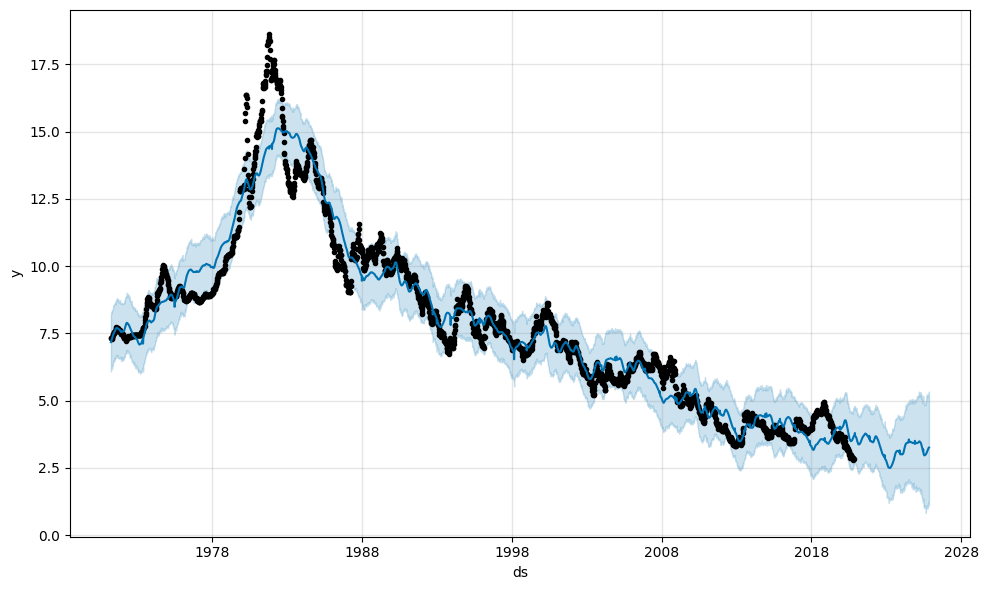

In [70]:
# Create a DataFrame of future dates for prediction, explicitly using the dates from df_test
# We'll also include the training dates so Prophet can generate a full forecast
future = pd.concat([df_train[['ds']], df_test[['ds']]])

# Make predictions using the aligned future dates
etd_forecast = prophet_etd.predict(future)

# Plot the forecast
fig = prophet_etd.plot(etd_forecast)
fig.show()

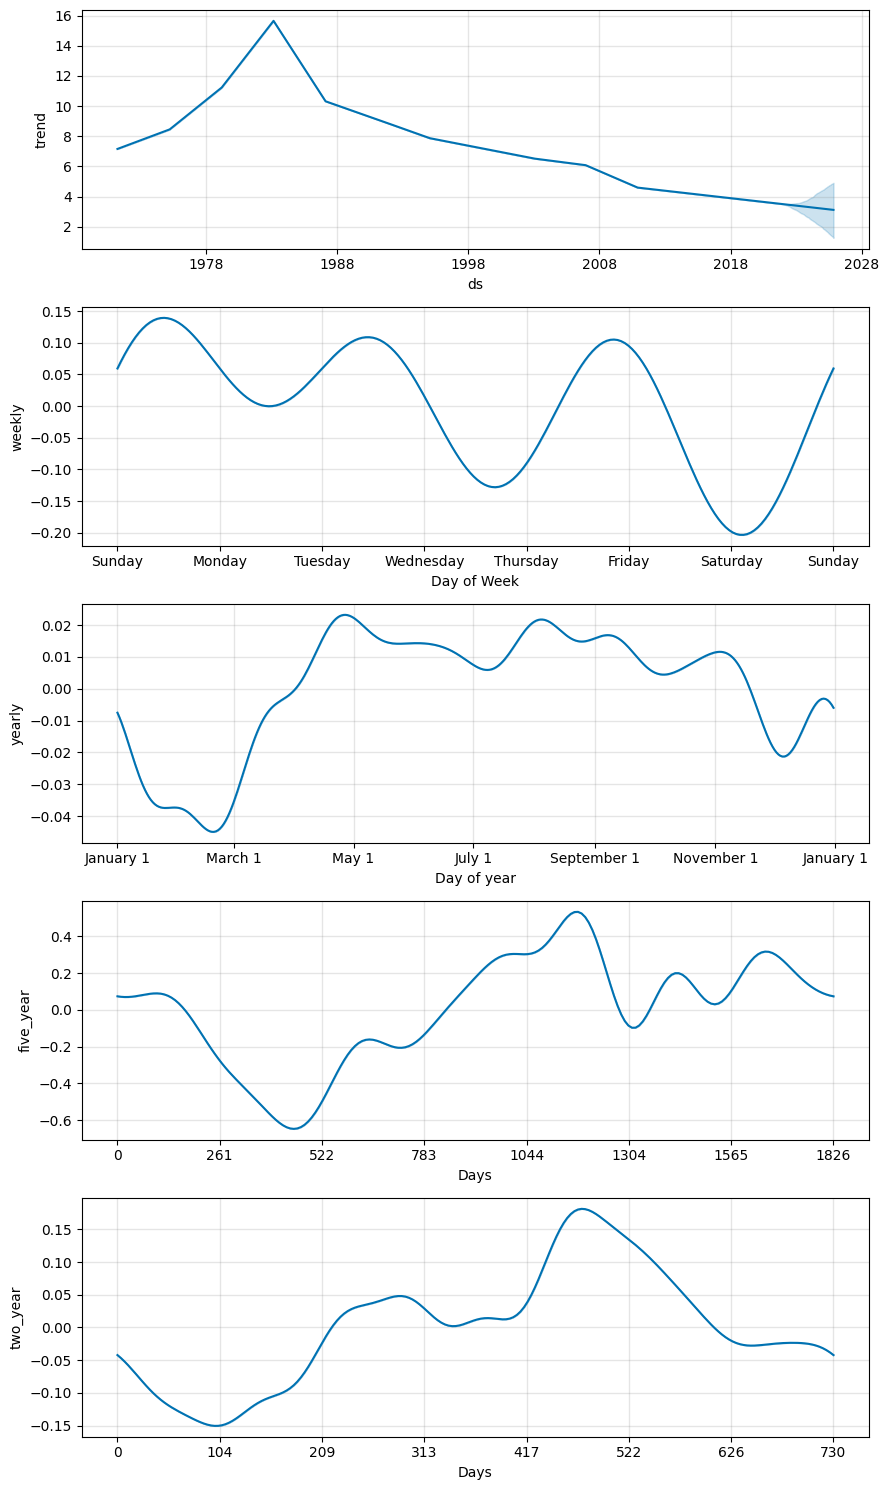

In [71]:
fig = prophet_etd.plot_components(etd_forecast)
fig.show()

In [68]:
# Below is AI generated because I had a couldn't match the dates to line up the forecast with the observed data

# Convert 'ds' column in df_test to datetime type for merging
df_test['ds'] = pd.to_datetime(df_test['ds'])

# Filter etd_forecast to only include the dates present in df_test
# This ensures we are only comparing the forecast for the test period
forecast_for_test = etd_forecast[etd_forecast['ds'].isin(df_test['ds'])][['ds', 'yhat']]

# Merge the filtered forecast with the actual test data
# Use an inner merge to ensure we only compare dates present in both the forecast and test set
merged_df = pd.merge(forecast_for_test, df_test, on='ds', how='inner')

# Rename columns for clarity
merged_df.rename(columns={'yhat': 'Predicted', 'y': 'Observed'}, inplace=True)

# Set 'ds' as index for easier plotting/analysis
merged_df.set_index('ds', inplace=True)

# Display the head of the merged dataframe
merged_df.head()

,Predicted,Observed
ds,,
2020-11-05,3.686703,2.78
2020-11-12,3.695980,2.84
2020-11-19,3.694330,2.72
2020-11-25,3.792035,2.72
2020-12-03,3.673061,2.71


In [69]:
fig = px.line(pd.DataFrame({'Observed': merged_df['Observed'], 'Predicted': merged_df['Predicted']},
                             index=merged_df.index,
                             ),
               title="Weekly Mortgage with Prophet Forecast",
               labels={"index": "Date", "value": "Mortgage"},
               template="seaborn",
               )
# shade predicted area
fig.add_vrect(x0=merged_df.index[0],
              x1=merged_df.index[-1],
              fillcolor="rgba(100,100,100)",
              opacity=0.2,
              line_width=0,
              )
fig.update_layout(title_font_size=30,
                  xaxis_tickfont_size=18,
                  yaxis_tickfont_size=18,
                  xaxis_title_font_size=25,
                  yaxis_title_font_size=25,
                  plot_bgcolor='rgba(0,0,0,0)',
                  )
fig.show()

The line when the Prophet model was using the training data seemed pretty good, but it seems to have continued following the trend influenced by the training data.

When looking at the forecasted plot 2 figures up, we can see that the mortgage rises to 7-8 over the course of 2023 and onwards which is even outside of the trendline's confidence intervals.

I would say the Prophet model does a poor job of predicting values starting from Decemeber 2021 since it completely misses the upward trend and continues trending down.